# Import packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.pipeline import Pipeline

# Load dataset

In [2]:
data = pd.read_csv('../input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car data.csv')
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# EDA

In [3]:
data.shape

(301, 9)

In [4]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
data.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(2)

In [8]:
data = data.drop_duplicates()

In [9]:
data.shape

(299, 9)

In [10]:
data['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

<Axes: xlabel='Fuel_Type', ylabel='count'>

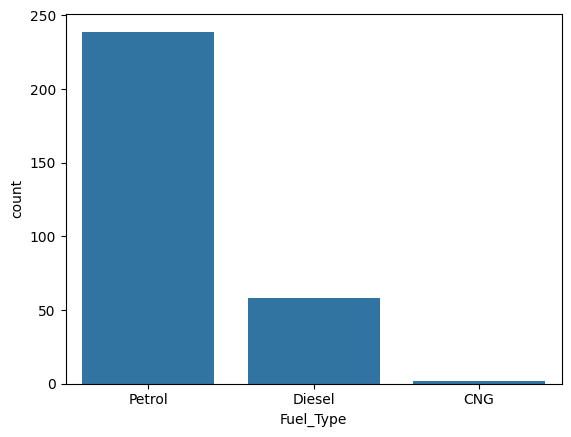

In [11]:
sns.countplot(data=data, x='Fuel_Type')

In [12]:
data['Seller_Type'].value_counts()

Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

<Axes: xlabel='Seller_Type', ylabel='count'>

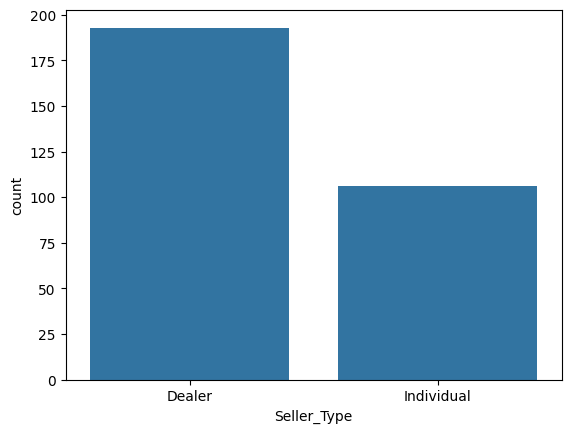

In [13]:
sns.countplot(data=data, x='Seller_Type')

In [14]:
data['Transmission'].value_counts()

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

<Axes: xlabel='Transmission', ylabel='count'>

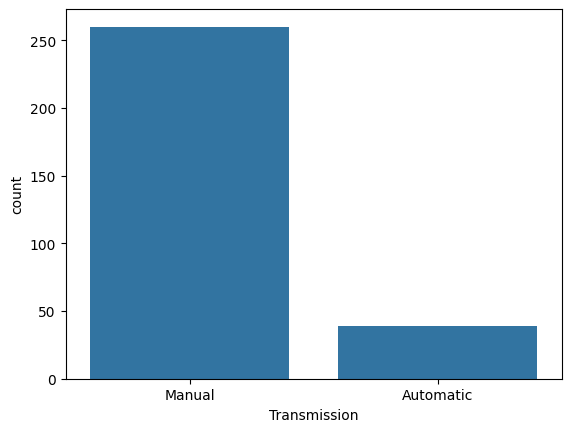

In [15]:
sns.countplot(data=data, x='Transmission')

In [16]:
data['Owner'].value_counts()

Owner
0    288
1     10
3      1
Name: count, dtype: int64

<Axes: xlabel='Owner', ylabel='count'>

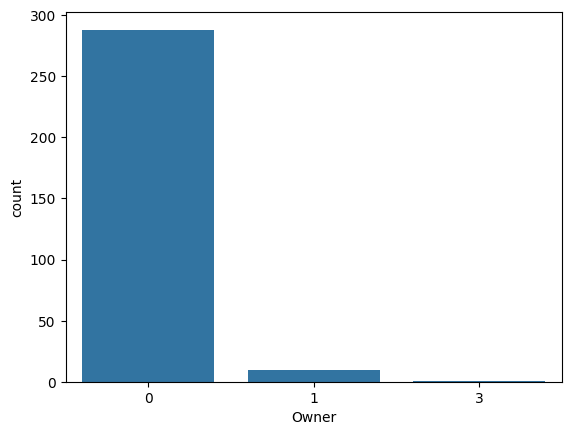

In [17]:
sns.countplot(data=data, x='Owner')

In [18]:
data["Car_Name"].unique()

array(['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza',
       's cross', 'alto 800', 'ertiga', 'dzire', 'alto k10', 'ignis',
       '800', 'baleno', 'omni', 'fortuner', 'innova', 'corolla altis',
       'etios cross', 'etios g', 'etios liva', 'corolla', 'etios gd',
       'camry', 'land cruiser', 'Royal Enfield Thunder 500',
       'UM Renegade Mojave', 'KTM RC200', 'Bajaj Dominar 400',
       'Royal Enfield Classic 350', 'KTM RC390', 'Hyosung GT250R',
       'Royal Enfield Thunder 350', 'KTM 390 Duke ',
       'Mahindra Mojo XT300', 'Bajaj Pulsar RS200',
       'Royal Enfield Bullet 350', 'Royal Enfield Classic 500',
       'Bajaj Avenger 220', 'Bajaj Avenger 150', 'Honda CB Hornet 160R',
       'Yamaha FZ S V 2.0', 'Yamaha FZ 16', 'TVS Apache RTR 160',
       'Bajaj Pulsar 150', 'Honda CBR 150', 'Hero Extreme',
       'Bajaj Avenger 220 dtsi', 'Bajaj Avenger 150 street',
       'Yamaha FZ  v 2.0', 'Bajaj Pulsar  NS 200', 'Bajaj Pulsar 220 F',
       'TVS Apache RTR 180', 

<Axes: xlabel='Year', ylabel='Count'>

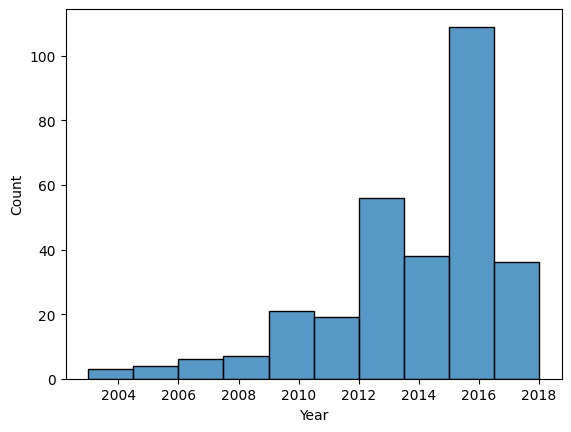

In [19]:
sns.histplot(data=data, x='Year', bins=10)

# outlier detection

<Axes: ylabel='Selling_Price'>

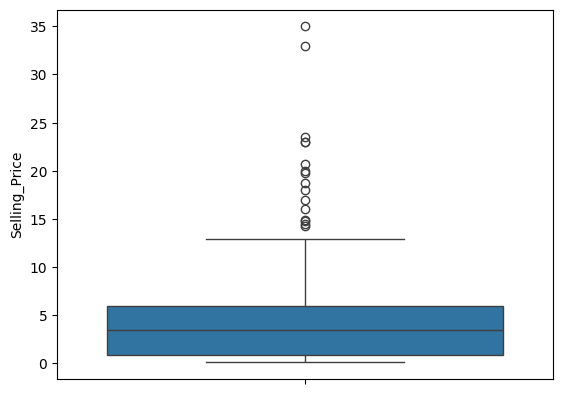

In [20]:
sns.boxplot(data['Selling_Price'])

<Axes: xlabel='Selling_Price', ylabel='Count'>

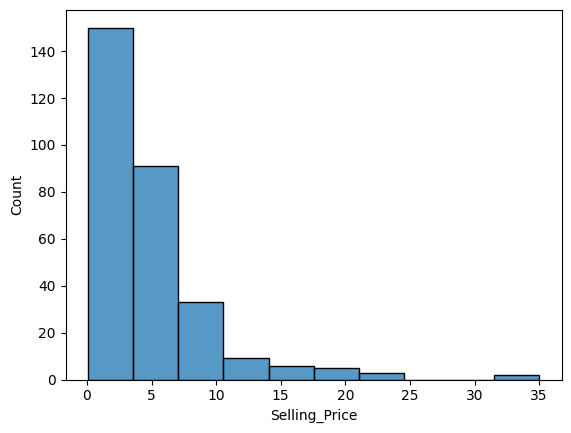

In [21]:
sns.histplot(data=data, x='Selling_Price', bins=10)

In [22]:
data = data[data['Selling_Price'] < 25]

<Axes: xlabel='Selling_Price', ylabel='Count'>

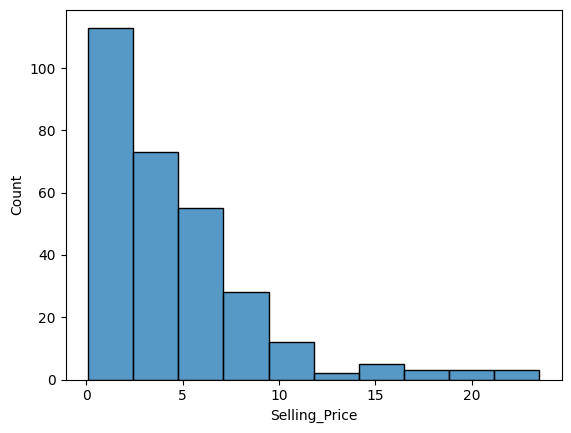

In [23]:
sns.histplot(data=data, x='Selling_Price', bins=10)

<Axes: ylabel='Present_Price'>

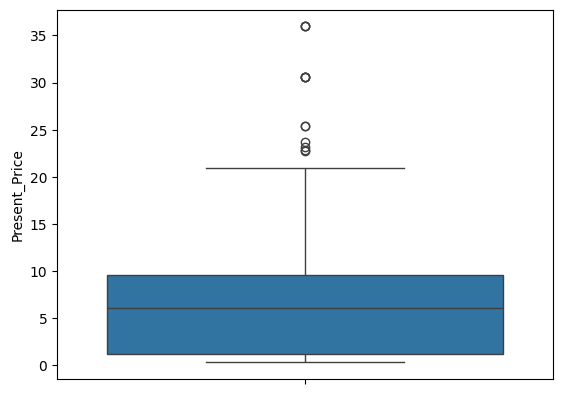

In [24]:
sns.boxplot(data['Present_Price'])

<Axes: xlabel='Present_Price', ylabel='Count'>

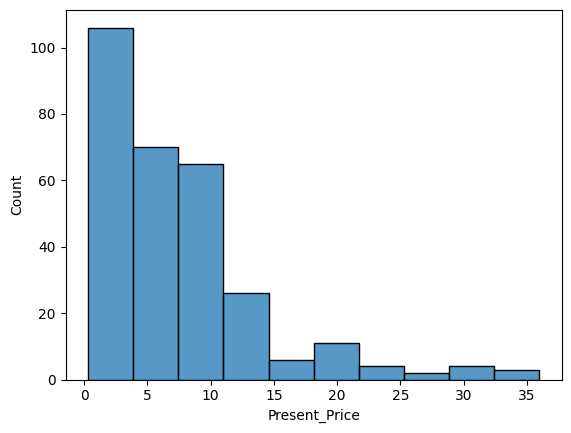

In [25]:
sns.histplot(data=data, x='Present_Price', bins=10)

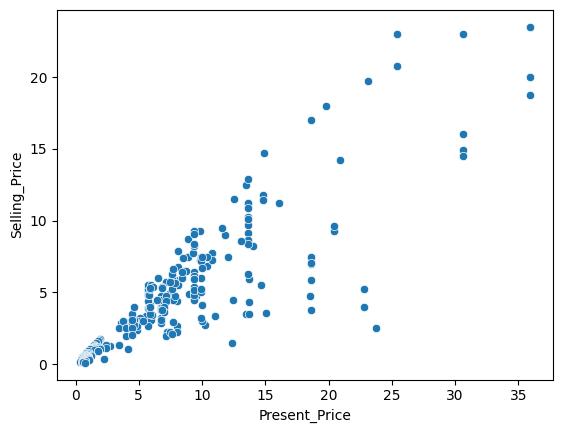

In [26]:
sns.scatterplot(data, x='Present_Price', y='Selling_Price')
plt.show()

<Axes: ylabel='Kms_Driven'>

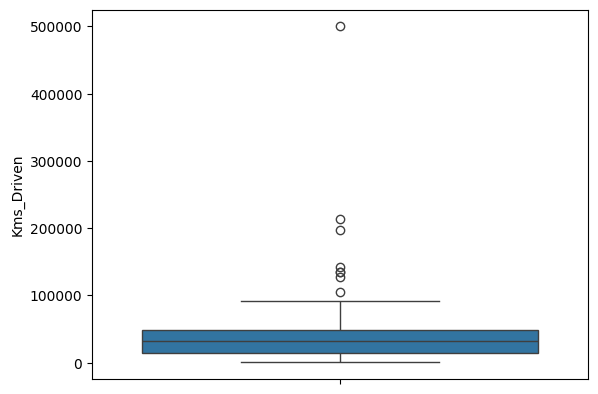

In [27]:
sns.boxplot(data['Kms_Driven'])

<Axes: xlabel='Kms_Driven', ylabel='Count'>

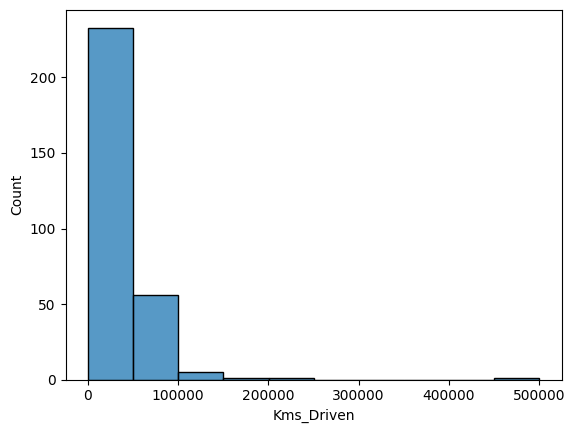

In [28]:
sns.histplot(data=data, x='Kms_Driven', bins=10)

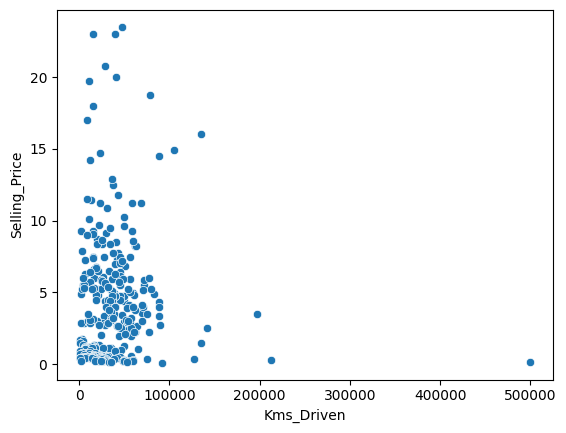

In [29]:
sns.scatterplot(data, x='Kms_Driven', y='Selling_Price')
plt.show()

In [30]:
data = data[data['Kms_Driven'] <= 150000]

In [31]:
data["Kms_Driven"] = np.log1p(data["Kms_Driven"])

<Axes: xlabel='Kms_Driven', ylabel='Count'>

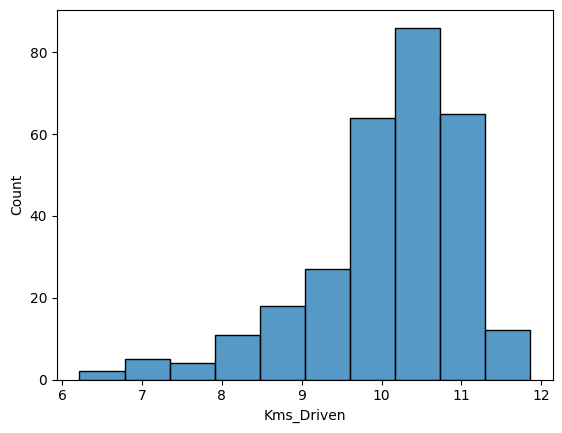

In [32]:
sns.histplot(data=data, x='Kms_Driven', bins=10)

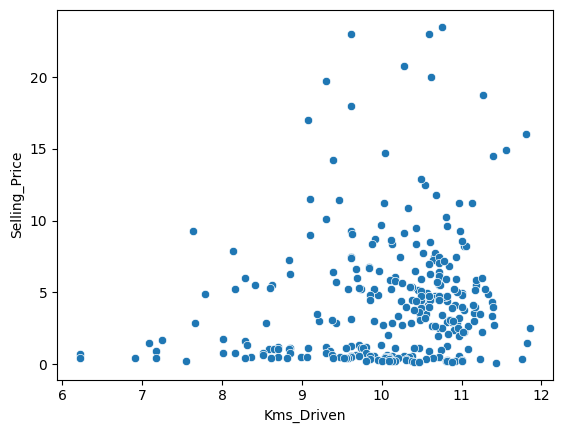

In [33]:
sns.scatterplot(data, x='Kms_Driven', y='Selling_Price')
plt.show()

# Data visualization

<Axes: xlabel='Kms_Driven', ylabel='Density'>

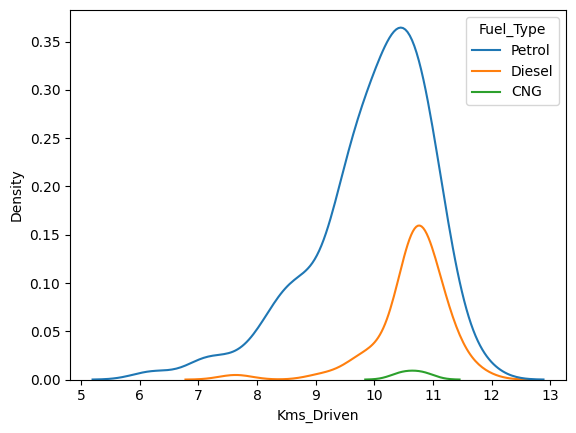

In [34]:
sns.kdeplot(data=data, x='Kms_Driven', hue='Fuel_Type')

<Axes: xlabel='Fuel_Type', ylabel='Selling_Price'>

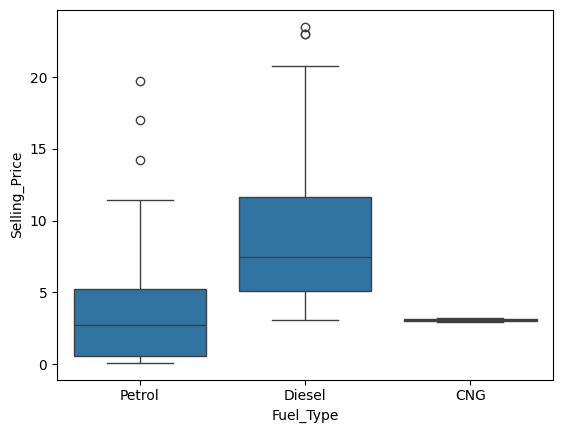

In [35]:
sns.boxplot(data=data,
            x='Fuel_Type',
            y='Selling_Price')

<Axes: xlabel='Transmission', ylabel='Selling_Price'>

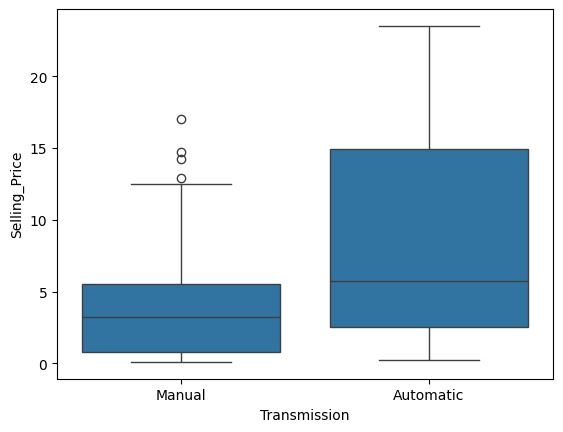

In [36]:
sns.boxplot(data=data,
            x='Transmission',
            y='Selling_Price')

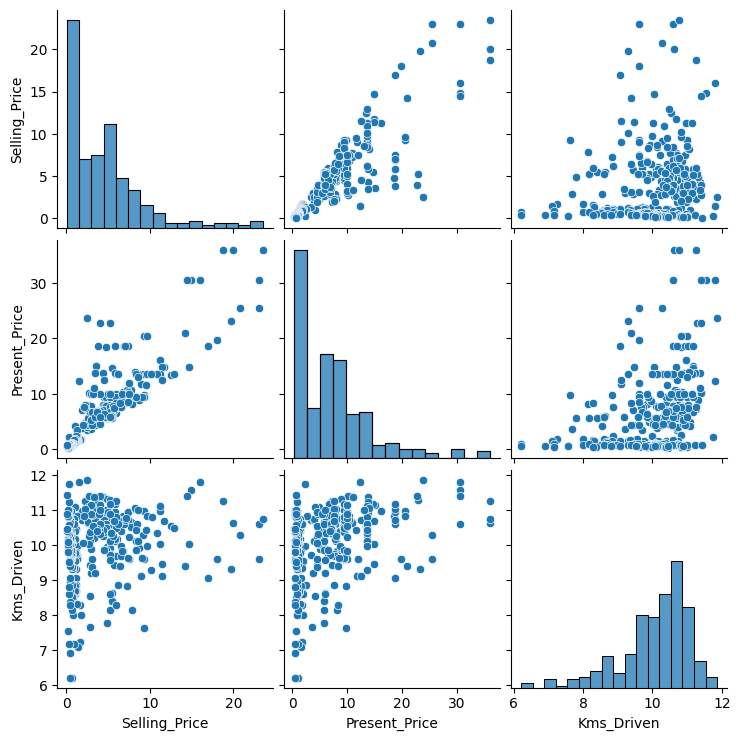

In [37]:
sns.pairplot(
    data[['Selling_Price',
          'Present_Price',
          'Kms_Driven']]
)

<Axes: xlabel='Present_Price', ylabel='Selling_Price'>

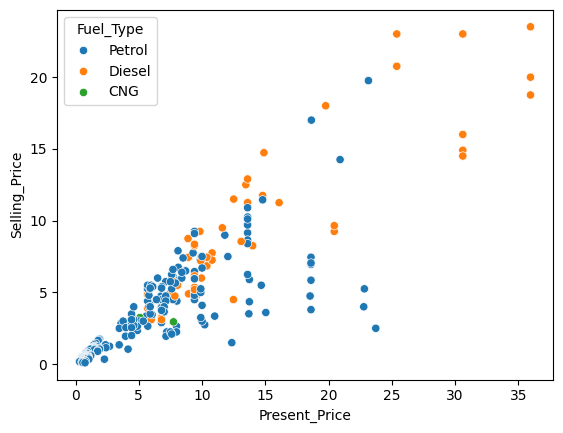

In [38]:
sns.scatterplot(
    data=data,
    x='Present_Price',
    y='Selling_Price',
    hue='Fuel_Type'
)

<Axes: xlabel='Present_Price', ylabel='Selling_Price'>

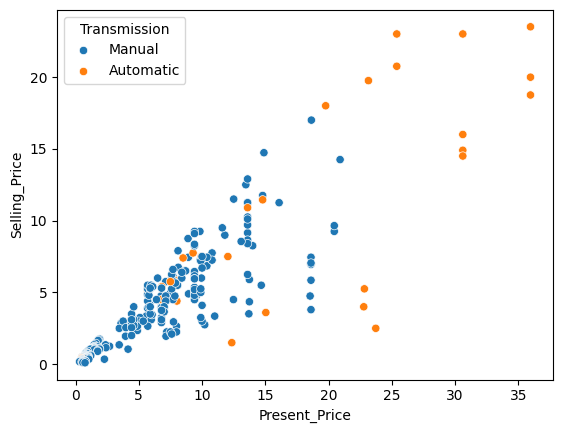

In [39]:
sns.scatterplot(
    data=data,
    x='Present_Price',
    y='Selling_Price',
    hue='Transmission'
)

# Correlation Analysis and Multicollinearity Detection

In [40]:
corr = data.corr(numeric_only=True)['Selling_Price'].sort_values(ascending=False)
corr

Selling_Price    1.000000
Present_Price    0.876563
Year             0.267964
Kms_Driven       0.166988
Owner           -0.094120
Name: Selling_Price, dtype: float64

<Axes: >

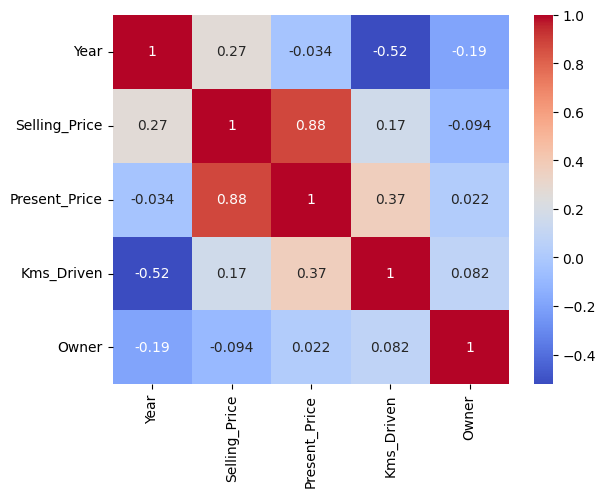

In [41]:
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

# Feature engineering

In [42]:
data["Car_Age"] = 2026 - data["Year"]

In [43]:
data = data.drop(['Year', 'Car_Name'], axis=1)

In [44]:
data.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,10.203629,Petrol,Dealer,Manual,0,12
1,4.75,9.54,10.668979,Diesel,Dealer,Manual,0,13
2,7.25,9.85,8.839422,Petrol,Dealer,Manual,0,9
3,2.85,4.15,8.556606,Petrol,Dealer,Manual,0,15
4,4.60,6.87,10.656106,Diesel,Dealer,Manual,0,12


# One-Hot Encoding

In [45]:
data = pd.get_dummies(data, drop_first=True)

In [46]:
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [47]:
data.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,10.203629,0,12,0,1,0,1
1,4.75,9.54,10.668979,0,13,1,0,0,1
2,7.25,9.85,8.839422,0,9,0,1,0,1
3,2.85,4.15,8.556606,0,15,0,1,0,1
4,4.60,6.87,10.656106,0,12,1,0,0,1


In [48]:
X = data.drop('Selling_Price', axis=1)
y = data['Selling_Price']

# Data splitting

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [50]:
print(f'X_train.shape = {X_train.shape}')
print(f'y_train.shape = {y_train.shape}')
print(f'X_test.shape = {X_test.shape}')
print(f'y_test.shape = {y_test.shape}')

X_train.shape = (205, 8)
y_train.shape = (205,)
X_test.shape = (89, 8)
y_test.shape = (89,)


# Data normalization

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ML Models

In [52]:
from sklearn.svm import SVR

svm = SVR(kernel='rbf', C=10)
svm.fit(X_train, y_train)

SVR(C=10)

In [53]:
y_pred_svm = svm.predict(X_test)

In [54]:
mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)
print("MAE:", mae_svm)
print("MSE:", mse_svm)
print("R²:", r2_svm)

MAE: 0.5492476827401942
MSE: 0.7912235180610008
R²: 0.9358190872044357


In [55]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [56]:
y_pred_dt = dt.predict(X_test)

In [57]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("R²:", r2_dt)

MAE: 0.9014909285471084
MSE: 3.0368280677584276
R²: 0.753664555030455


In [58]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, max_depth=5)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=50)

In [59]:
y_pred_rf = rf.predict(X_test)

In [60]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R²:", r2_rf)

MAE: 0.7377904369783645
MSE: 2.056715532617432
R²: 0.8331673955196754


In [61]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [62]:
y_pred_knn = knn.predict(X_test)

In [63]:
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
print("MAE:", mae_knn)
print("MSE:", mse_knn)
print("R²:", r2_knn)

MAE: 0.9537827715355804
MSE: 2.301588264669163
R²: 0.8133042909694742


In [64]:
from xgboost import XGBRegressor

xgboost = XGBRegressor()
xgboost.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [65]:
y_pred_xgboost = xgboost.predict(X_test)

In [66]:
mae_xgboost = mean_absolute_error(y_test, y_pred_xgboost)
mse_xgboost = mean_squared_error(y_test, y_pred_xgboost)
r2_xgboost = r2_score(y_test, y_pred_xgboost)
print("MAE:", mae_xgboost)
print("MSE:", mse_xgboost)
print("R²:", r2_xgboost)

MAE: 0.7203185551220112
MSE: 2.049295570007155
R²: 0.8337692734496991


In [67]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=30, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=30, random_state=42)

In [68]:
y_pred_gb = gb.predict(X_test)

In [69]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
print("MAE:", mae_gb)
print("MSE:", mse_gb)
print("R²:", r2_gb)

MAE: 0.721184824564507
MSE: 1.6099121407675019
R²: 0.8694103140812441


In [70]:
data_df = pd.DataFrame({
    'Models': [
        'SVM',
        'Decision Tree',
        'Random Forest', 
        'KNN',
        'XGBoost',
        'Gradient Boosting'
    ],
    'Mean Absolute Error': [
        mae_svm, 
        mae_dt,
        mae_rf,
        mae_knn,
        mae_xgboost,
        mae_gb
    ],
    'Mean Squared Error': [
        mse_svm, 
        mse_dt,
        mse_rf,
        mse_knn,
        mse_xgboost,
        mse_gb
    ],
    'R2_Score': [
        r2_svm, 
        r2_dt,
        r2_rf,
        r2_knn,
        r2_xgboost,
        r2_gb
    ]
}).sort_values(by='R2_Score', ascending=False)

In [71]:
data_df

,Models,Mean Absolute Error,Mean Squared Error,R2_Score
0,SVM,0.549248,0.791224,0.935819
5,Gradient Boosting,0.721185,1.609912,0.869410
4,XGBoost,0.720319,2.049296,0.833769
2,Random Forest,0.737790,2.056716,0.833167
3,KNN,0.953783,2.301588,0.813304
1,Decision Tree,0.901491,3.036828,0.753665


# Cross validation

In [72]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    'RidgeCV': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RidgeCV(
            alphas=[0.001, 0.01, 0.1, 1, 10, 100]
        ))
    ]),
    'LassoCV': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LassoCV(
            alphas=[0.001, 0.01, 0.1, 1, 10, 100],
            cv=5,
            random_state=42
        ))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(
            n_neighbors=7,
            weights='distance'
        ))
    ]),
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR(
            kernel='rbf',
            C=10,
            gamma='scale'
        ))
    ]),
    'Decision Tree': DecisionTreeRegressor(
        max_depth=5,
        min_samples_split=5,
        random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=42,
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        subsample=0.8,
        random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring='r2'
    )
    print(f'\n{name}')
    print(f'Mean R2 {scores.mean()}')
    print(f'Std R2 {scores.std()}')


RidgeCV
Mean R2 0.7976506535219569
Std R2 0.12219257891666037

LassoCV
Mean R2 0.8046264659599986
Std R2 0.12069961445296704

KNN
Mean R2 0.8814240239795439
Std R2 0.05061990222547398

SVR
Mean R2 0.9531385700655541
Std R2 0.012894951264136003

Decision Tree
Mean R2 0.8429807652013658
Std R2 0.16975227602039777

Random Forest
Mean R2 0.9313756665858846
Std R2 0.07028105868692193

Gradient Boosting
Mean R2 0.9523119452729117
Std R2 0.03339457884417296

XGBoost
Mean R2 0.9552205947273233
Std R2 0.020442531059421922


In [73]:
results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring='r2'
    )

    results.append({
        'Model':name,
        'Mean_R2':scores.mean(),
        'Std_R2':scores.std()
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='Mean_R2',
    ascending=False
).reset_index(drop=True)

In [74]:
results_df

,Model,Mean_R2,Std_R2
0,XGBoost,0.955221,0.020443
1,SVR,0.953139,0.012895
2,Gradient Boosting,0.952312,0.033395
3,Random Forest,0.931376,0.070281
4,KNN,0.881424,0.050620
5,Decision Tree,0.842981,0.169752
6,LassoCV,0.804626,0.120700
7,RidgeCV,0.797651,0.122193


# The best model is XGBoost